# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [12]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv(r"C:\Users\gurud\Downloads\data-viz-class-material-master (1)\data-viz-class-material-master\data\netflix_catalogue.csv")
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [ ]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


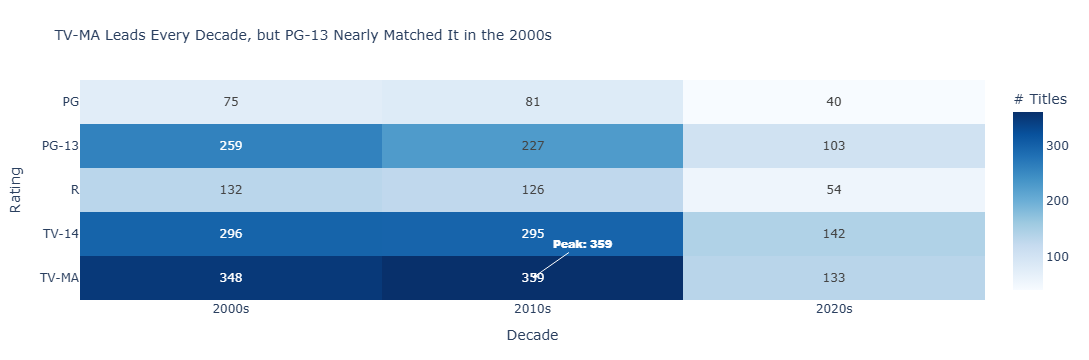

In [11]:
# Task 1
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

df = pd.read_csv(r"C:\Users\gurud\Downloads\data-viz-class-material-master (1)\data-viz-class-material-master\data\netflix_catalogue.csv")

# --- prep ---
df["decade"] = (df["release_year"] // 10 * 10).astype(str) + "s"
ratings = ["TV-14", "TV-MA", "PG-13", "R", "PG"]
df_filtered = df[df["rating"].isin(ratings)]

pivot = (
    df_filtered
    .groupby(["rating", "decade"])
    .size()
    .reset_index(name="count")
    .pivot(index="rating", columns="decade", values="count")
    .fillna(0)
    .astype(int)
)

pivot = pivot[sorted(pivot.columns.tolist())]

# --- plot ---
fig = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale="Blues",
    labels={"x": "Decade", "y": "Rating", "color": "Titles"},
    title="TV-MA Leads Every Decade, but PG-13 Nearly Matched It in the 2000s",
    aspect="auto",
)

# annotate peak cell (TV-MA, 2010s = 359)
ratings_order = list(pivot.index)
decades_order = list(pivot.columns)
peak_row = ratings_order.index("TV-MA")
peak_col = decades_order.index("2010s")

fig.add_annotation(
    x=peak_col, y=peak_row,
    text="Peak: 359",
    showarrow=True, arrowhead=2,
    font=dict(color="white", size=11, family="Arial Black"),
    arrowcolor="white", ax=50, ay=-35,
)

fig.update_layout(
    title_font_size=14,
    coloraxis_colorbar_title="# Titles",
    margin=dict(t=80, l=80, r=20, b=60),
)
fig.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


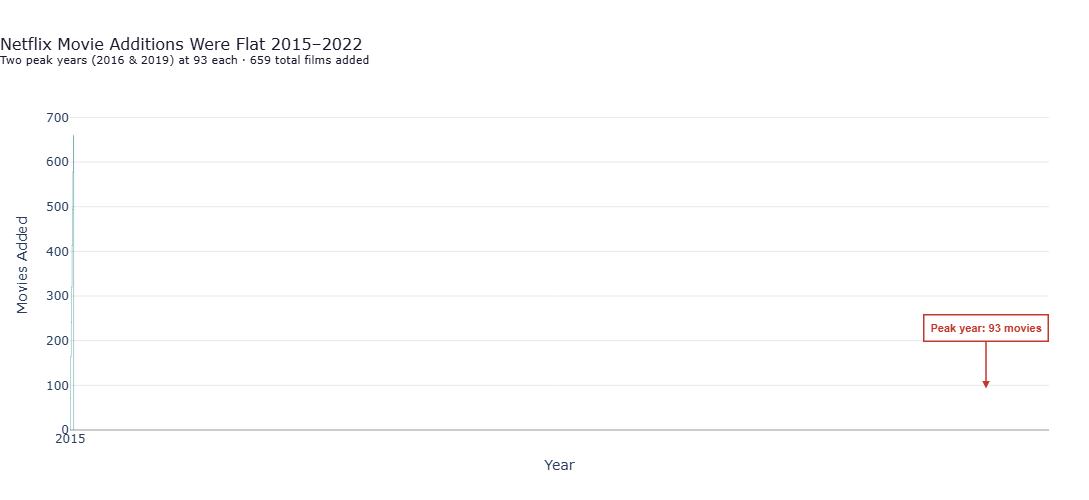

In [10]:
# Task 2
# YOUR CODE HERE
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv(r"C:\Users\gurud\Downloads\data-viz-class-material-master (1)\data-viz-class-material-master\data\netflix_catalogue.csv")

movies = (
    df[(df["type"] == "Movie") & (df["added_year"].between(2015, 2022))]
    .groupby("added_year")
    .size()
    .reset_index(name="count")
    .sort_values("added_year")
)

peak_year = str(int(movies.loc[movies["count"].idxmax(), "added_year"]))
peak_val = int(movies["count"].max())
cumulative_total = int(movies["count"].sum())

x_labels = [str(int(y)) for y in movies["added_year"]] + ["Total"]
measures = ["relative"] * len(movies) + ["total"]
y_values = list(movies["count"]) + [cumulative_total]
bar_texts = [str(v) for v in y_values]

fig = go.Figure(
    go.Waterfall(
        orientation="v",
        measure=measures,
        x=x_labels,
        y=y_values,
        text=bar_texts,
        textposition="outside",
        textfont=dict(size=12),
        increasing=dict(marker=dict(color="#2a9461")),
        totals=dict(marker=dict(color="#1565a8")),
        decreasing=dict(marker=dict(color="#e74c3c")),
        connector=dict(
            visible=True,
            line=dict(color="rgba(120,120,120,0.4)", width=1, dash="dot")
        ),
    )
)

fig.add_annotation(
    x=peak_year,
    y=peak_val,
    text="<b>Peak year: 93 movies</b>",
    showarrow=True,
    arrowhead=2,
    arrowcolor="#c0392b",
    arrowwidth=1.5,
    font=dict(size=11, color="#c0392b", family="Arial"),
    bgcolor="rgba(255,255,255,0.9)",
    bordercolor="#c0392b",
    borderwidth=1.5,
    borderpad=6,
    ax=0,
    ay=-60,
    xanchor="center",
)

fig.update_layout(
    title=dict(
        text="Netflix Movie Additions Were Flat 2015–2022<br><sup>Two peak years (2016 & 2019) at 93 each · 659 total films added</sup>",
        font=dict(size=16, color="#1a1a2e"),
        x=0,
    ),
    yaxis=dict(
        title="Movies Added",
        gridcolor="#e8e8e8",
        zeroline=True,
        zerolinecolor="#cccccc",
        range=[0, cumulative_total + 80],
    ),
    xaxis=dict(
        title="Year",
        type="category",
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    margin=dict(t=100, b=70, l=70, r=40),
    width=850,
    height=500,
)

fig.show()